# Análise de desempenho de jogadores de futebol

## Este notebook utiliza o dataset European Soccer Database do kaggle que contem dados de partidas das temporadas 2008 a 2016 do futebol profissional europeu.

### Sobre o conjunto de dados

#### No kaggle o conjunto de dados é descrito como: "The ultimate Soccer database for data analysis and machine learning"

#### O dataset contém:

* +25,000 matches
* +10,000 players
* 11 European Countries with their lead championship
* Seasons 2008 to 2016
* Players and Teams' attributes* sourced from EA Sports' FIFA video game series, including the weekly updates
* Team line up with squad formation (X, Y coordinates)
* Betting odds from up to 10 providers
* Detailed match events (goal types, possession, corner, cross, fouls, cards etc…) for +10,000 matches

### Objetivo do notebook é responder as perguntas:

* Quem são os jogadores mais eficientes?
* Como a evolução acontece ao longo do tempo?
* Quais atributos influenciam o desempenho?
* Qual é o perfil ideal de jogador?

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")
from pathlib import Path

### Funções

In [2]:
# Função para realizar consultas no banco de dados SQLite
def db_query(query):
    # Obtem o caminho absoluta da pasta do notebook
    notebook_dir = Path().resolve()
    # Define o caminho para o banco de dados SQLite
    database_path = notebook_dir.parent.parent / 'data' / 'raw' / 'database.sqlite'

    if not database_path.exists():
        raise FileNotFoundError("O banco de dados não foi encontrado no caminho especificado.")
    
    con = sqlite3.connect(database_path)
    result = pd.read_sql_query(query, con)
    con.close()
    return result

In [3]:
# Função para verificar valores nulos em um DataFrame
def nulls(df):
    print("Valores nulos por coluna:")
    print(df.isnull().sum())

In [4]:
# Função para limpar os nomes dos jogadores, removendo aspas, vírgula e números extras
def nameCorrector(df, column):
    return df[column].str.replace(r'^"|,\d+$', '', regex=True).str.strip()

## Pipeline final

In [5]:
# Query para extrair do banco de dados os dados dos jogadores e suas avaliações ao longo do tempo, incluindo atributos técnicos
query_players_df = """
SELECT 
    p.player_api_id, 
    p.player_name, 
    p.birthday, 
    pa.date, 
    pa.overall_rating, 
    pa.potential, 
    pa.crossing, 
    pa.finishing, 
    pa.heading_accuracy, 
    pa.short_passing, 
    pa.volleys, 
    pa.dribbling, 
    pa.curve, 
    pa.free_kick_accuracy, 
    pa.long_passing, 
    pa.ball_control, 
    pa.acceleration, 
    pa.sprint_speed, 
    pa.agility, 
    pa.reactions, 
    pa.balance, 
    pa.shot_power, 
    pa.jumping, 
    pa.stamina, 
    pa.strength, 
    pa.long_shots, 
    pa.aggression, 
    pa.interceptions, 
    pa.positioning, 
    pa.vision, 
    pa.penalties, 
    pa.marking, 
    pa.standing_tackle, 
    pa.sliding_tackle
FROM Player p
INNER JOIN Player_Attributes pa ON p.player_api_id = pa.player_api_id
ORDER BY p.player_api_id, pa.date;
"""

In [6]:
# Executar a consulta e armazenar os resultados em um DataFrame
players_df = db_query(query_players_df)
players_df

,player_api_id,player_name,birthday,date,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,...,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle
0,2625,"Patryk Rachwal,18",1981-01-27 00:00:00,2007-02-22 00:00:00,63.0,64.0,48.0,48.0,47.0,64.0,...,56.0,59.0,72.0,52.0,55.0,56.0,46.0,64.0,66.0,63.0
1,2625,"Patryk Rachwal,18",1981-01-27 00:00:00,2007-08-30 00:00:00,63.0,64.0,48.0,48.0,47.0,64.0,...,56.0,59.0,72.0,52.0,55.0,56.0,46.0,64.0,66.0,63.0
2,2625,"Patryk Rachwal,18",1981-01-27 00:00:00,2008-08-30 00:00:00,60.0,64.0,48.0,48.0,47.0,64.0,...,56.0,59.0,72.0,52.0,55.0,56.0,46.0,64.0,66.0,63.0
3,2625,"Patryk Rachwal,18",1981-01-27 00:00:00,2010-08-30 00:00:00,60.0,64.0,48.0,48.0,47.0,64.0,...,56.0,59.0,72.0,71.0,50.0,56.0,69.0,64.0,66.0,63.0
4,2625,"Patryk Rachwal,18",1981-01-27 00:00:00,2011-02-22 00:00:00,59.0,63.0,52.0,47.0,46.0,63.0,...,55.0,58.0,71.0,70.0,49.0,55.0,66.0,63.0,63.0,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183973,750435,Rees Greenwood,1996-01-20 00:00:00,2016-02-04 00:00:00,56.0,70.0,35.0,57.0,55.0,60.0,...,46.0,50.0,34.0,13.0,56.0,58.0,61.0,18.0,19.0,21.0
183974,750435,Rees Greenwood,1996-01-20 00:00:00,2016-02-11 00:00:00,56.0,70.0,35.0,57.0,55.0,60.0,...,46.0,50.0,34.0,13.0,56.0,58.0,61.0,18.0,19.0,21.0
183975,750435,Rees Greenwood,1996-01-20 00:00:00,2016-04-14 00:00:00,60.0,74.0,35.0,57.0,55.0,60.0,...,46.0,50.0,34.0,13.0,59.0,58.0,61.0,18.0,19.0,21.0
183976,750584,Alexandre Azevedo,1997-01-28 00:00:00,2007-02-22 00:00:00,58.0,66.0,47.0,39.0,53.0,60.0,...,57.0,38.0,62.0,56.0,41.0,47.0,52.0,56.0,66.0,62.0


### Verificação da quantidade de valores nulos em cada coluna do dataframe.

In [7]:
# Verificar valores nulos no DataFrame resultante
nulls(players_df)

Valores nulos por coluna:
player_api_id            0
player_name              0
birthday                 0
date                     0
overall_rating         836
potential              836
crossing               836
finishing              836
heading_accuracy       836
short_passing          836
volleys               2713
dribbling              836
curve                 2713
free_kick_accuracy     836
long_passing           836
ball_control           836
acceleration           836
sprint_speed           836
agility               2713
reactions              836
balance               2713
shot_power             836
jumping               2713
stamina                836
strength               836
long_shots             836
aggression             836
interceptions          836
positioning            836
vision                2713
penalties              836
marking                836
standing_tackle        836
sliding_tackle        2713
dtype: int64


### Trata valores ausentes removendo os registros com valores nulos na coluna overall_rating.

In [8]:
# Remover registros com valores nulos na coluna 'overall_rating' para resolver o problema de valores nulos e garantir que estamos analisando apenas jogadores com avaliações completas
players_attributes = players_df.dropna(subset=['overall_rating'])
players_attributes

,player_api_id,player_name,birthday,date,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,...,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle
0,2625,"Patryk Rachwal,18",1981-01-27 00:00:00,2007-02-22 00:00:00,63.0,64.0,48.0,48.0,47.0,64.0,...,56.0,59.0,72.0,52.0,55.0,56.0,46.0,64.0,66.0,63.0
1,2625,"Patryk Rachwal,18",1981-01-27 00:00:00,2007-08-30 00:00:00,63.0,64.0,48.0,48.0,47.0,64.0,...,56.0,59.0,72.0,52.0,55.0,56.0,46.0,64.0,66.0,63.0
2,2625,"Patryk Rachwal,18",1981-01-27 00:00:00,2008-08-30 00:00:00,60.0,64.0,48.0,48.0,47.0,64.0,...,56.0,59.0,72.0,52.0,55.0,56.0,46.0,64.0,66.0,63.0
3,2625,"Patryk Rachwal,18",1981-01-27 00:00:00,2010-08-30 00:00:00,60.0,64.0,48.0,48.0,47.0,64.0,...,56.0,59.0,72.0,71.0,50.0,56.0,69.0,64.0,66.0,63.0
4,2625,"Patryk Rachwal,18",1981-01-27 00:00:00,2011-02-22 00:00:00,59.0,63.0,52.0,47.0,46.0,63.0,...,55.0,58.0,71.0,70.0,49.0,55.0,66.0,63.0,63.0,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183973,750435,Rees Greenwood,1996-01-20 00:00:00,2016-02-04 00:00:00,56.0,70.0,35.0,57.0,55.0,60.0,...,46.0,50.0,34.0,13.0,56.0,58.0,61.0,18.0,19.0,21.0
183974,750435,Rees Greenwood,1996-01-20 00:00:00,2016-02-11 00:00:00,56.0,70.0,35.0,57.0,55.0,60.0,...,46.0,50.0,34.0,13.0,56.0,58.0,61.0,18.0,19.0,21.0
183975,750435,Rees Greenwood,1996-01-20 00:00:00,2016-04-14 00:00:00,60.0,74.0,35.0,57.0,55.0,60.0,...,46.0,50.0,34.0,13.0,59.0,58.0,61.0,18.0,19.0,21.0
183976,750584,Alexandre Azevedo,1997-01-28 00:00:00,2007-02-22 00:00:00,58.0,66.0,47.0,39.0,53.0,60.0,...,57.0,38.0,62.0,56.0,41.0,47.0,52.0,56.0,66.0,62.0


### Trasnforma as colunas date e birthday no tipo datetime para facilitar a manipulação de datas e cálculos relacionados à idade dos jogadores.

In [9]:
# Transformar as colunas date e birthday para o tipo datetime para facilitar a manipulação de datas e cálculos relacionados à idade dos jogadores
players_attributes['date'] = pd.to_datetime(players_attributes['date'])
players_attributes['birthday'] = pd.to_datetime(players_attributes['birthday'])
players_attributes

,player_api_id,player_name,birthday,date,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,...,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle
0,2625,"Patryk Rachwal,18",1981-01-27,2007-02-22,63.0,64.0,48.0,48.0,47.0,64.0,...,56.0,59.0,72.0,52.0,55.0,56.0,46.0,64.0,66.0,63.0
1,2625,"Patryk Rachwal,18",1981-01-27,2007-08-30,63.0,64.0,48.0,48.0,47.0,64.0,...,56.0,59.0,72.0,52.0,55.0,56.0,46.0,64.0,66.0,63.0
2,2625,"Patryk Rachwal,18",1981-01-27,2008-08-30,60.0,64.0,48.0,48.0,47.0,64.0,...,56.0,59.0,72.0,52.0,55.0,56.0,46.0,64.0,66.0,63.0
3,2625,"Patryk Rachwal,18",1981-01-27,2010-08-30,60.0,64.0,48.0,48.0,47.0,64.0,...,56.0,59.0,72.0,71.0,50.0,56.0,69.0,64.0,66.0,63.0
4,2625,"Patryk Rachwal,18",1981-01-27,2011-02-22,59.0,63.0,52.0,47.0,46.0,63.0,...,55.0,58.0,71.0,70.0,49.0,55.0,66.0,63.0,63.0,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183973,750435,Rees Greenwood,1996-01-20,2016-02-04,56.0,70.0,35.0,57.0,55.0,60.0,...,46.0,50.0,34.0,13.0,56.0,58.0,61.0,18.0,19.0,21.0
183974,750435,Rees Greenwood,1996-01-20,2016-02-11,56.0,70.0,35.0,57.0,55.0,60.0,...,46.0,50.0,34.0,13.0,56.0,58.0,61.0,18.0,19.0,21.0
183975,750435,Rees Greenwood,1996-01-20,2016-04-14,60.0,74.0,35.0,57.0,55.0,60.0,...,46.0,50.0,34.0,13.0,59.0,58.0,61.0,18.0,19.0,21.0
183976,750584,Alexandre Azevedo,1997-01-28,2007-02-22,58.0,66.0,47.0,39.0,53.0,60.0,...,57.0,38.0,62.0,56.0,41.0,47.0,52.0,56.0,66.0,62.0


In [10]:
nulls(players_attributes)

Valores nulos por coluna:
player_api_id            0
player_name              0
birthday                 0
date                     0
overall_rating           0
potential                0
crossing                 0
finishing                0
heading_accuracy         0
short_passing            0
volleys               1877
dribbling                0
curve                 1877
free_kick_accuracy       0
long_passing             0
ball_control             0
acceleration             0
sprint_speed             0
agility               1877
reactions                0
balance               1877
shot_power               0
jumping               1877
stamina                  0
strength                 0
long_shots               0
aggression               0
interceptions            0
positioning              0
vision                1877
penalties                0
marking                  0
standing_tackle          0
sliding_tackle        1877
dtype: int64


### Corrige nomes fora do padrão em player_name. A coluna player_name do dataser possui nomes fora do padrão contendo aspas, vírgula e numeros.

In [11]:
# Limpar os nomes dos jogadores, removendo aspas, vírgula e números extras
players_attributes['player_name'] = nameCorrector(players_attributes, 'player_name')
players_attributes

,player_api_id,player_name,birthday,date,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,...,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle
0,2625,Patryk Rachwal,1981-01-27,2007-02-22,63.0,64.0,48.0,48.0,47.0,64.0,...,56.0,59.0,72.0,52.0,55.0,56.0,46.0,64.0,66.0,63.0
1,2625,Patryk Rachwal,1981-01-27,2007-08-30,63.0,64.0,48.0,48.0,47.0,64.0,...,56.0,59.0,72.0,52.0,55.0,56.0,46.0,64.0,66.0,63.0
2,2625,Patryk Rachwal,1981-01-27,2008-08-30,60.0,64.0,48.0,48.0,47.0,64.0,...,56.0,59.0,72.0,52.0,55.0,56.0,46.0,64.0,66.0,63.0
3,2625,Patryk Rachwal,1981-01-27,2010-08-30,60.0,64.0,48.0,48.0,47.0,64.0,...,56.0,59.0,72.0,71.0,50.0,56.0,69.0,64.0,66.0,63.0
4,2625,Patryk Rachwal,1981-01-27,2011-02-22,59.0,63.0,52.0,47.0,46.0,63.0,...,55.0,58.0,71.0,70.0,49.0,55.0,66.0,63.0,63.0,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183973,750435,Rees Greenwood,1996-01-20,2016-02-04,56.0,70.0,35.0,57.0,55.0,60.0,...,46.0,50.0,34.0,13.0,56.0,58.0,61.0,18.0,19.0,21.0
183974,750435,Rees Greenwood,1996-01-20,2016-02-11,56.0,70.0,35.0,57.0,55.0,60.0,...,46.0,50.0,34.0,13.0,56.0,58.0,61.0,18.0,19.0,21.0
183975,750435,Rees Greenwood,1996-01-20,2016-04-14,60.0,74.0,35.0,57.0,55.0,60.0,...,46.0,50.0,34.0,13.0,59.0,58.0,61.0,18.0,19.0,21.0
183976,750584,Alexandre Azevedo,1997-01-28,2007-02-22,58.0,66.0,47.0,39.0,53.0,60.0,...,57.0,38.0,62.0,56.0,41.0,47.0,52.0,56.0,66.0,62.0


### Cira as colunas year e month para permitir análises temporais como a evolução de atributos ao longo do tempo e age_at_rating que permite comparar jogadores de diferentes idades e entender como os atributos evoluem com o envelhecimento.

In [12]:
# Cria as colunas yiear, month e age_at_rating para facilitar análises temporais e relacionadas à idade dos jogadores
players_attributes['year'] = players_attributes['date'].dt.year
players_attributes['month'] = players_attributes['date'].dt.month
players_attributes['age_at_rating'] = ((players_attributes['date'] - players_attributes['birthday']).dt.days // 365.25).astype(int)
players_attributes

,player_api_id,player_name,birthday,date,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,...,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle,year,month,age_at_rating
0,2625,Patryk Rachwal,1981-01-27,2007-02-22,63.0,64.0,48.0,48.0,47.0,64.0,...,52.0,55.0,56.0,46.0,64.0,66.0,63.0,2007,2,26
1,2625,Patryk Rachwal,1981-01-27,2007-08-30,63.0,64.0,48.0,48.0,47.0,64.0,...,52.0,55.0,56.0,46.0,64.0,66.0,63.0,2007,8,26
2,2625,Patryk Rachwal,1981-01-27,2008-08-30,60.0,64.0,48.0,48.0,47.0,64.0,...,52.0,55.0,56.0,46.0,64.0,66.0,63.0,2008,8,27
3,2625,Patryk Rachwal,1981-01-27,2010-08-30,60.0,64.0,48.0,48.0,47.0,64.0,...,71.0,50.0,56.0,69.0,64.0,66.0,63.0,2010,8,29
4,2625,Patryk Rachwal,1981-01-27,2011-02-22,59.0,63.0,52.0,47.0,46.0,63.0,...,70.0,49.0,55.0,66.0,63.0,63.0,62.0,2011,2,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183973,750435,Rees Greenwood,1996-01-20,2016-02-04,56.0,70.0,35.0,57.0,55.0,60.0,...,13.0,56.0,58.0,61.0,18.0,19.0,21.0,2016,2,20
183974,750435,Rees Greenwood,1996-01-20,2016-02-11,56.0,70.0,35.0,57.0,55.0,60.0,...,13.0,56.0,58.0,61.0,18.0,19.0,21.0,2016,2,20
183975,750435,Rees Greenwood,1996-01-20,2016-04-14,60.0,74.0,35.0,57.0,55.0,60.0,...,13.0,59.0,58.0,61.0,18.0,19.0,21.0,2016,4,20
183976,750584,Alexandre Azevedo,1997-01-28,2007-02-22,58.0,66.0,47.0,39.0,53.0,60.0,...,56.0,41.0,47.0,52.0,56.0,66.0,62.0,2007,2,10


In [13]:
# Lista de todas as colunas de atributos técnicos (da coluna 'overall_rating' até a última)
tecnic_columns = players_attributes.columns[players_attributes.columns.get_loc('overall_rating'):]

# Criar o dicionário básico: média para todos os atributos técnicos
agg_dict = {col: 'mean' for col in tecnic_columns}

# Ajustes específicos para colunas que não devem ser médias
agg_dict['potential'] = 'max'      # Queremos o teto de potencial do ano
agg_dict['age_at_rating'] = 'max'  # A idade atingida naquele ano

# Remover 'year' e 'month' do dicionário de agregação, pois são usadas para agrupamento
if 'year' in agg_dict: del agg_dict['year']
if 'month' in agg_dict: del agg_dict['month']

# Realiza o GroupBy usando o dicionário de agregação
player_evolution_master = players_attributes.groupby(['player_api_id', 'player_name', 'year']).agg(agg_dict).reset_index()

# Removemos qualquer registro anual que tenha atributos incompletos
player_evolution_master = player_evolution_master.dropna()

player_evolution_master

,player_api_id,player_name,year,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,...,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle,age_at_rating
0,2625,Patryk Rachwal,2007,63.000000,64.0,48.0,48.0,47.0,64.0,38.0,...,59.0,72.0,52.0,55.0,56.0,46.0,64.0,66.0,63.0,26
1,2625,Patryk Rachwal,2008,60.000000,64.0,48.0,48.0,47.0,64.0,38.0,...,59.0,72.0,52.0,55.0,56.0,46.0,64.0,66.0,63.0,27
2,2625,Patryk Rachwal,2010,60.000000,64.0,48.0,48.0,47.0,64.0,38.0,...,59.0,72.0,71.0,50.0,56.0,69.0,64.0,66.0,63.0,29
3,2625,Patryk Rachwal,2011,58.500000,63.0,52.0,47.0,46.0,58.0,37.0,...,58.0,71.0,65.0,49.0,55.0,66.0,63.0,63.0,57.0,30
4,2625,Patryk Rachwal,2012,58.000000,58.0,52.0,47.0,46.0,53.0,37.0,...,58.0,71.0,64.0,49.0,55.0,66.0,63.0,63.0,52.0,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73054,750435,Rees Greenwood,2007,56.000000,70.0,35.0,57.0,55.0,60.0,52.0,...,50.0,34.0,13.0,56.0,58.0,61.0,18.0,19.0,21.0,11
73055,750435,Rees Greenwood,2015,56.000000,70.0,35.0,57.0,55.0,60.0,52.0,...,50.0,34.0,13.0,56.0,58.0,61.0,18.0,19.0,21.0,19
73056,750435,Rees Greenwood,2016,57.333333,74.0,35.0,57.0,55.0,60.0,52.0,...,50.0,34.0,13.0,57.0,58.0,61.0,18.0,19.0,21.0,20
73057,750584,Alexandre Azevedo,2007,58.000000,66.0,47.0,39.0,53.0,60.0,37.0,...,38.0,62.0,56.0,41.0,47.0,52.0,56.0,66.0,62.0,10


In [14]:
nulls(player_evolution_master)

Valores nulos por coluna:
player_api_id         0
player_name           0
year                  0
overall_rating        0
potential             0
crossing              0
finishing             0
heading_accuracy      0
short_passing         0
volleys               0
dribbling             0
curve                 0
free_kick_accuracy    0
long_passing          0
ball_control          0
acceleration          0
sprint_speed          0
agility               0
reactions             0
balance               0
shot_power            0
jumping               0
stamina               0
strength              0
long_shots            0
aggression            0
interceptions         0
positioning           0
vision                0
penalties             0
marking               0
standing_tackle       0
sliding_tackle        0
age_at_rating         0
dtype: int64


### Filtra os jogadores com 5 ou mais avaliações para aumentar a confiabilidade da análise reduzindo o ruido causado por avaliações únicas ou esporádicas de jogadores que tiveram poucas aparições como, por exemplo, jogadores em final de carreira no período em que os dados foram produzidos.

In [15]:
# Identificar jogadores com pelo menos 5 avaliações anuais
years_of_evaluation = player_evolution_master.groupby('player_api_id').size()

# Filtrar os jogadores que possuem pelo menos 5 avaliações anuais para garantir uma análise mais robusta
jogadores_estaveis = years_of_evaluation[years_of_evaluation >= 5].index

# Criar um DataFrame final contendo apenas os jogadores que possuem pelo menos 5 avaliações anuais
player_evolution_final = player_evolution_master[player_evolution_master['player_api_id'].isin(jogadores_estaveis)]
player_evolution_final

,player_api_id,player_name,year,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,...,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle,age_at_rating
0,2625,Patryk Rachwal,2007,63.0,64.0,48.00,48.0,47.00,64.0,38.00,...,59.00,72.00,52.00,55.0,56.00,46.00,64.00,66.00,63.00,26
1,2625,Patryk Rachwal,2008,60.0,64.0,48.00,48.0,47.00,64.0,38.00,...,59.00,72.00,52.00,55.0,56.00,46.00,64.00,66.00,63.00,27
2,2625,Patryk Rachwal,2010,60.0,64.0,48.00,48.0,47.00,64.0,38.00,...,59.00,72.00,71.00,50.0,56.00,69.00,64.00,66.00,63.00,29
3,2625,Patryk Rachwal,2011,58.5,63.0,52.00,47.0,46.00,58.0,37.00,...,58.00,71.00,65.00,49.0,55.00,66.00,63.00,63.00,57.00,30
4,2625,Patryk Rachwal,2012,58.0,58.0,52.00,47.0,46.00,53.0,37.00,...,58.00,71.00,64.00,49.0,55.00,66.00,63.00,63.00,52.00,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72671,643232,Kenji Gorre,2007,62.0,75.0,58.00,58.0,51.00,59.0,42.00,...,49.00,42.00,35.00,60.0,55.00,60.00,29.00,35.00,32.00,12
72672,643232,Kenji Gorre,2013,62.0,75.0,58.00,58.0,51.00,59.0,42.00,...,49.00,42.00,35.00,60.0,55.00,60.00,29.00,35.00,32.00,18
72673,643232,Kenji Gorre,2014,61.0,75.0,58.00,58.0,39.00,59.0,42.00,...,49.00,42.00,35.00,60.0,55.00,51.00,29.00,35.00,32.00,20
72674,643232,Kenji Gorre,2015,64.0,75.0,58.75,60.0,39.75,62.0,50.25,...,61.75,42.75,35.75,61.5,60.25,51.75,29.75,35.75,32.75,21


In [16]:
# Selecionamos apenas tipos numéricos e excluímos o ID do jogador para facilitar a análise de correlação e outras análises estatísticas
numeric_player_evolution = player_evolution_final.select_dtypes(include=[np.number]).drop(columns=['player_api_id'], errors='ignore')

correlacao = numeric_player_evolution.corr()['overall_rating'].sort_values(ascending=False)

print("Atributos que mais influenciam o Overall Rating:")
print(correlacao)

Atributos que mais influenciam o Overall Rating:
overall_rating        1.000000
potential             0.749564
reactions             0.741417
short_passing         0.448856
long_passing          0.440652
ball_control          0.431378
vision                0.427312
age_at_rating         0.425186
penalties             0.419521
shot_power            0.419319
positioning           0.384280
long_shots            0.377195
strength              0.376165
stamina               0.356535
crossing              0.348667
aggression            0.346083
dribbling             0.345103
free_kick_accuracy    0.334867
heading_accuracy      0.333812
volleys               0.328886
curve                 0.320425
finishing             0.318720
interceptions         0.302891
jumping               0.278899
sprint_speed          0.277992
acceleration          0.269771
year                  0.227884
agility               0.218351
balance               0.197789
standing_tackle       0.183053
marking              

In [18]:
# Calcular a amplitude de avaliação (diferença entre a avaliação máxima e mínima) para cada jogador
amplitude = (player_evolution_final.groupby(['player_api_id', 'player_name'])['overall_rating']
             .agg(lambda x: x.max() - x.min())
             .reset_index()
             .rename(columns={'overall_rating': 'rating_growth'}))

# Adicionar a coluna de amplitude ao DataFrame final para análise posterior
player_evolution_final = pd.merge(player_evolution_final, amplitude, on=['player_api_id', 'player_name'])
player_evolution_final

,player_api_id,player_name,year,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,...,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle,age_at_rating,rating_growth
0,2625,Patryk Rachwal,2007,63.0,64.0,48.00,48.0,47.00,64.0,38.00,...,72.00,52.00,55.0,56.00,46.00,64.00,66.00,63.00,26,5.0
1,2625,Patryk Rachwal,2008,60.0,64.0,48.00,48.0,47.00,64.0,38.00,...,72.00,52.00,55.0,56.00,46.00,64.00,66.00,63.00,27,5.0
2,2625,Patryk Rachwal,2010,60.0,64.0,48.00,48.0,47.00,64.0,38.00,...,72.00,71.00,50.0,56.00,69.00,64.00,66.00,63.00,29,5.0
3,2625,Patryk Rachwal,2011,58.5,63.0,52.00,47.0,46.00,58.0,37.00,...,71.00,65.00,49.0,55.00,66.00,63.00,63.00,57.00,30,5.0
4,2625,Patryk Rachwal,2012,58.0,58.0,52.00,47.0,46.00,53.0,37.00,...,71.00,64.00,49.0,55.00,66.00,63.00,63.00,52.00,31,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64217,643232,Kenji Gorre,2007,62.0,75.0,58.00,58.0,51.00,59.0,42.00,...,42.00,35.00,60.0,55.00,60.00,29.00,35.00,32.00,12,4.0
64218,643232,Kenji Gorre,2013,62.0,75.0,58.00,58.0,51.00,59.0,42.00,...,42.00,35.00,60.0,55.00,60.00,29.00,35.00,32.00,18,4.0
64219,643232,Kenji Gorre,2014,61.0,75.0,58.00,58.0,39.00,59.0,42.00,...,42.00,35.00,60.0,55.00,51.00,29.00,35.00,32.00,20,4.0
64220,643232,Kenji Gorre,2015,64.0,75.0,58.75,60.0,39.75,62.0,50.25,...,42.75,35.75,61.5,60.25,51.75,29.75,35.75,32.75,21,4.0


## Análise Exploratória de Dados (EDA)

### 1. Evolução Média de Rating por Ano

Este gráfico mostra como o nível geral dos jogadores evoluiu ao longo do tempo, indicando tendências de desempenho na liga.

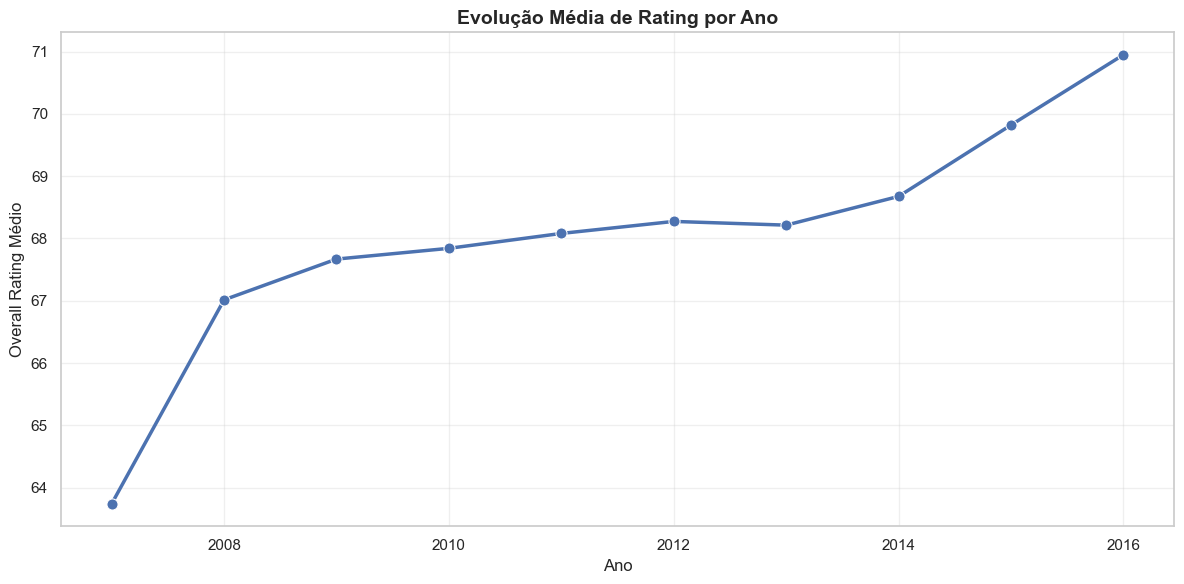

Rating médio inicial (2008): 67.01
Rating médio final (2016): 70.95


In [19]:
avg_rating_by_year = player_evolution_final.groupby('year')['overall_rating'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_rating_by_year, x='year', y='overall_rating', marker='o', linewidth=2.5, markersize=8)
plt.title('Evolução Média de Rating por Ano', fontsize=14, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Overall Rating Médio', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Rating médio inicial (2008): {avg_rating_by_year[avg_rating_by_year['year'] == 2008]['overall_rating'].values[0]:.2f}")
print(f"Rating médio final (2016): {avg_rating_by_year[avg_rating_by_year['year'] == 2016]['overall_rating'].values[0]:.2f}")

### 2. Distribuição de Amplitude de Rating (Crescimento)

Este histograma mostra como os jogadores distribuem-se em termos de crescimento de rating. Uma amplitude alta indica jugadores que evoluíram significativamente durante o período analisado.

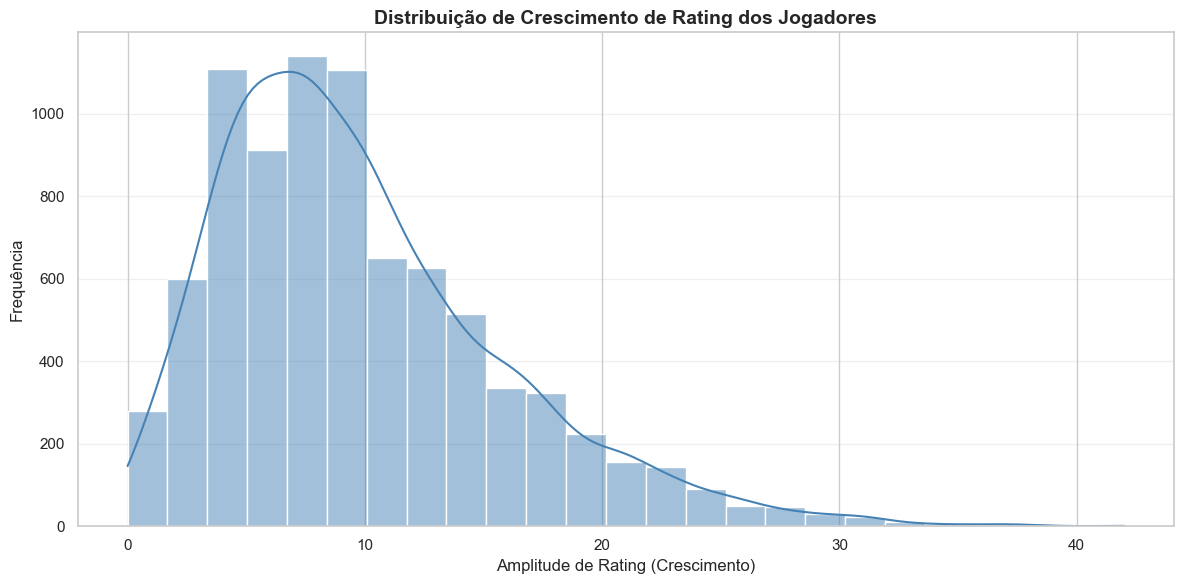

Crescimento médio: 9.82
Crescimento mínimo: 0.00
Crescimento máximo: 42.00
Mediana de crescimento: 8.67


In [20]:
plt.figure(figsize=(12, 6))
sns.histplot(amplitude['rating_growth'], bins=25, kde=True, color='steelblue')
plt.title('Distribuição de Crescimento de Rating dos Jogadores', fontsize=14, fontweight='bold')
plt.xlabel('Amplitude de Rating (Crescimento)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Crescimento médio: {amplitude['rating_growth'].mean():.2f}")
print(f"Crescimento mínimo: {amplitude['rating_growth'].min():.2f}")
print(f"Crescimento máximo: {amplitude['rating_growth'].max():.2f}")
print(f"Mediana de crescimento: {amplitude['rating_growth'].median():.2f}")

### 3. Relação entre Idade e Overall Rating

Este gráfico de dispersão revela se há uma correlação entre a idade do jogador e seu desempenho geral. A transparência permite visualizar a densidade de jogadores em cada faixa etária.

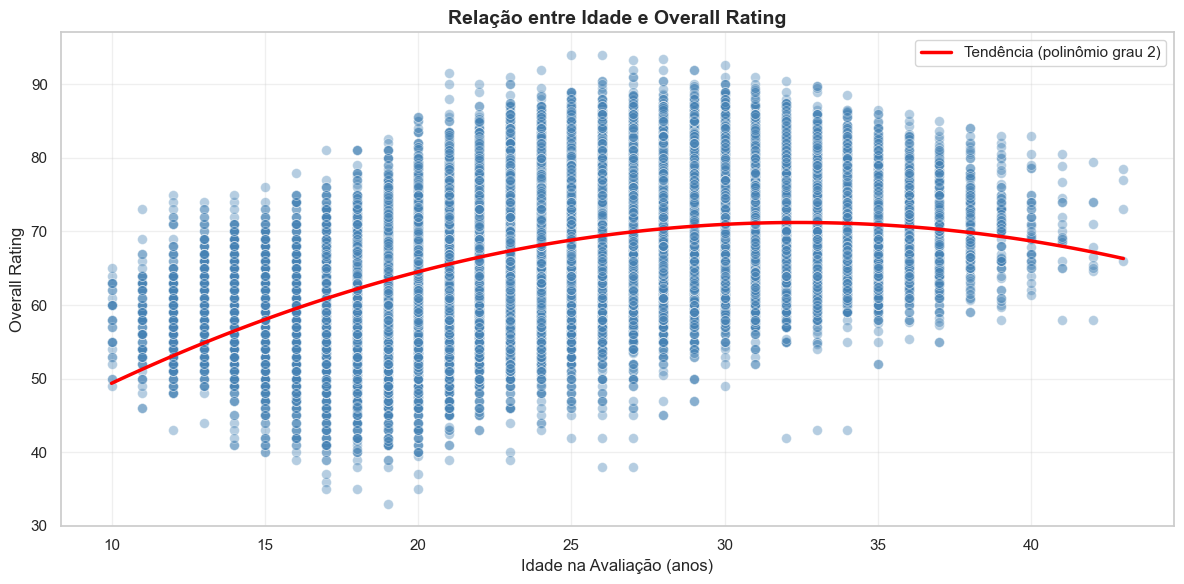

Correlação entre idade e overall_rating: 0.4252
Idade média dos jogadores: 25.1 anos
Idade com maior rating médio: 43 anos


In [21]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=player_evolution_final, x='age_at_rating', y='overall_rating', alpha=0.4, s=50, color='steelblue')

# Adicionar uma linha de tendência
z = np.polyfit(player_evolution_final['age_at_rating'].dropna(), 
               player_evolution_final.loc[player_evolution_final['age_at_rating'].notna(), 'overall_rating'], 2)
p = np.poly1d(z)
x_trend = np.linspace(player_evolution_final['age_at_rating'].min(), 
                       player_evolution_final['age_at_rating'].max(), 100)
plt.plot(x_trend, p(x_trend), color='red', linewidth=2.5, label='Tendência (polinômio grau 2)')

plt.title('Relação entre Idade e Overall Rating', fontsize=14, fontweight='bold')
plt.xlabel('Idade na Avaliação (anos)', fontsize=12)
plt.ylabel('Overall Rating', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calcular correlação
idade_rating_corr = player_evolution_final[['age_at_rating', 'overall_rating']].corr().iloc[0, 1]
print(f"Correlação entre idade e overall_rating: {idade_rating_corr:.4f}")
print(f"Idade média dos jogadores: {player_evolution_final['age_at_rating'].mean():.1f} anos")
print(f"Idade com maior rating médio: {player_evolution_final.groupby('age_at_rating')['overall_rating'].mean().idxmax()} anos")

### 5. Top 10 Atributos Técnicos mais Correlacionados com Overall Rating

Este gráfico destaca os atributos técnicos que mais influenciam o desempenho geral do jogador. Uma correlação mais alta indica uma relação mais forte entre o atributo e o rating geral.

### 4. Mapa de Calor das Correlações entre Atributos Técnicos

Este heatmap mostra a correlação completa entre todos os atributos técnicos dos jogadores. Valores próximos de 1 indicam forte correlação positiva, próximos de -1 indicam correlação negativa, e próximos de 0 indicam pouca ou nenhuma correlação.

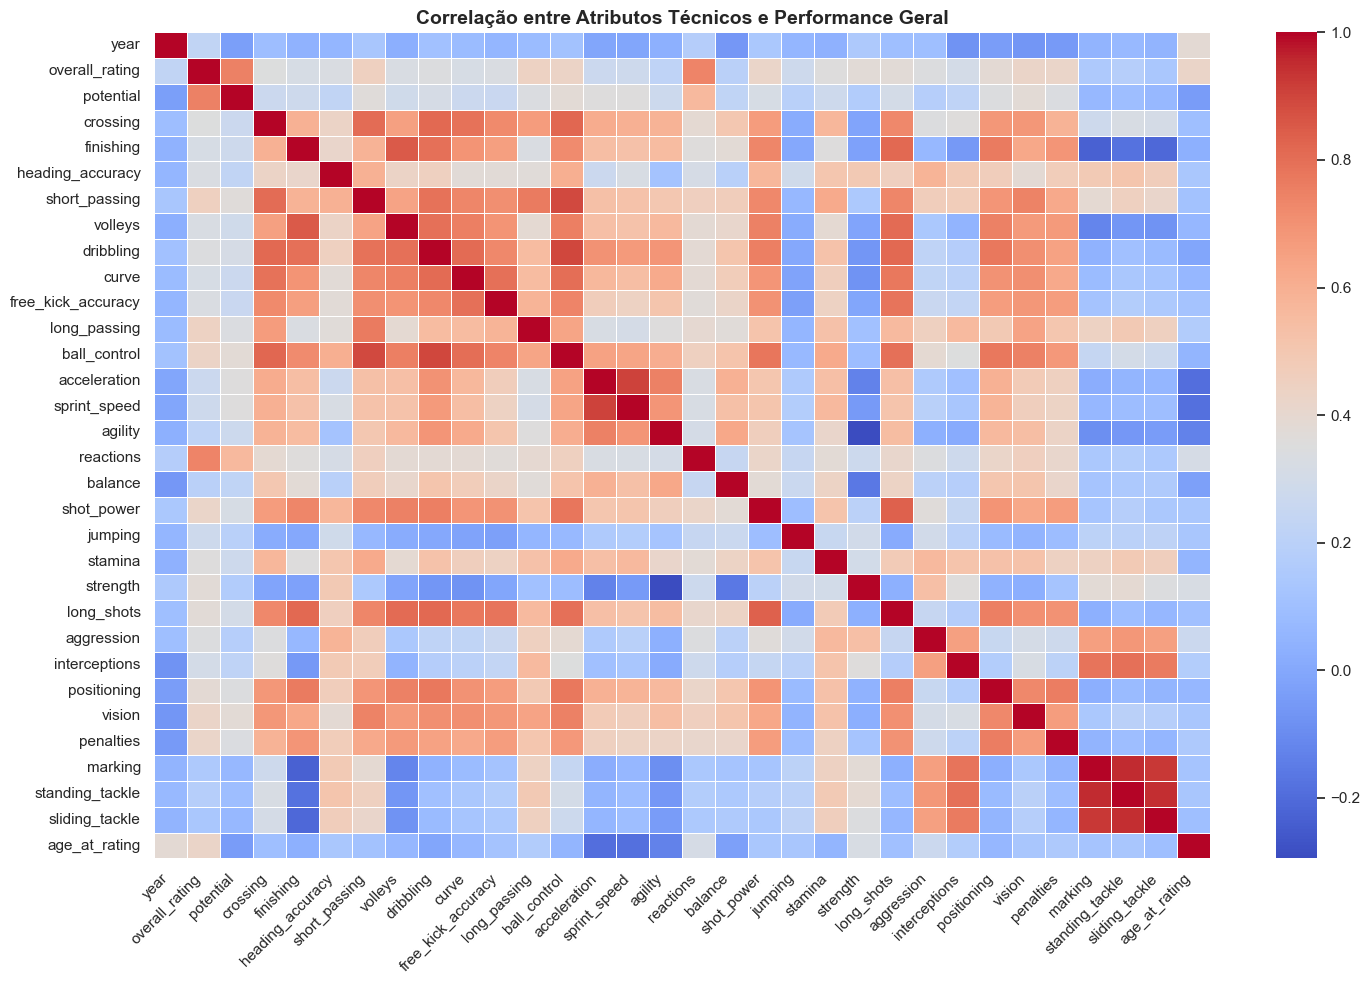

In [25]:
plt.figure(figsize=(15, 10))
sns.heatmap(numeric_player_evolution.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlação entre Atributos Técnicos e Performance Geral', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\leand\AppData\Local\Temp\ipykernel_24688\2649008486.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=top_10_correlation.values, y=top_10_correlation.index, palette='viridis')


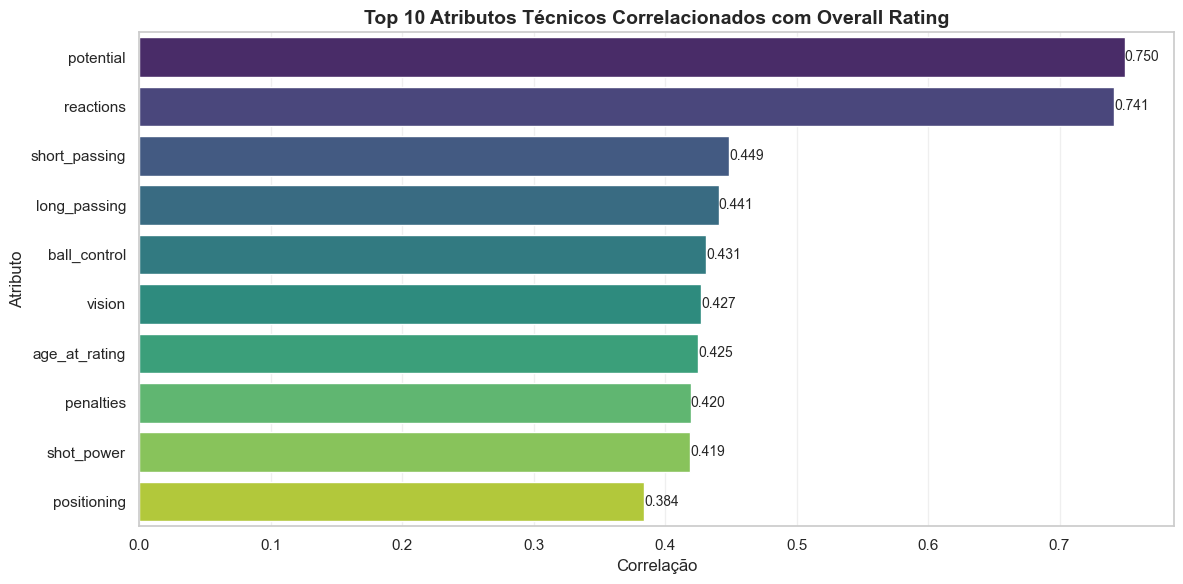


Top 10 Atributos e suas Correlações com Overall Rating:
potential        0.749564
reactions        0.741417
short_passing    0.448856
long_passing     0.440652
ball_control     0.431378
vision           0.427312
age_at_rating    0.425186
penalties        0.419521
shot_power       0.419319
positioning      0.384280
Name: overall_rating, dtype: float64


In [22]:
top_10_correlation = correlacao[1:11]  # Excluir 'overall_rating' (correlação perfeita consigo mesmo)

plt.figure(figsize=(12, 6))
bars = sns.barplot(x=top_10_correlation.values, y=top_10_correlation.index, palette='viridis')
plt.title('Top 10 Atributos Técnicos Correlacionados com Overall Rating', fontsize=14, fontweight='bold')
plt.xlabel('Correlação', fontsize=12)
plt.ylabel('Atributo', fontsize=12)

# Adicionar valores nas barras
for i, bar in enumerate(bars.patches):
    width = bar.get_width()
    bars.text(width, bar.get_y() + bar.get_height()/2, 
              f'{width:.3f}', ha='left', va='center', fontsize=10)

plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTop 10 Atributos e suas Correlações com Overall Rating:")
print(top_10_correlation)

### 6. Top 10 Jogadores com Maior Crescimento de Rating

Esta tabela mostra os jogadores que mais evoluíram durante o período analisado, indicando os maiores promissores e aqueles que mais se desenvolveram em suas carreiras.

Top 10 Jogadores com Maior Crescimento de Rating
              player_name  rating_growth
1              Marco Reus      42.000000
2   Francesco Della Rocca      38.166667
3             Bakary Sako      38.000000
4             Eden Hazard      37.400000
5        Radja Nainggolan      37.000000
6       Ricardo Rodriguez      37.000000
7         Oscar de Marcos      37.000000
8        Leonardo Bonucci      36.000000
9             Lamine Kone      36.000000
10        Haris Seferovic      35.600000


C:\Users\leand\AppData\Local\Temp\ipykernel_24688\2614376740.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=amplitude.nlargest(10, 'rating_growth'),


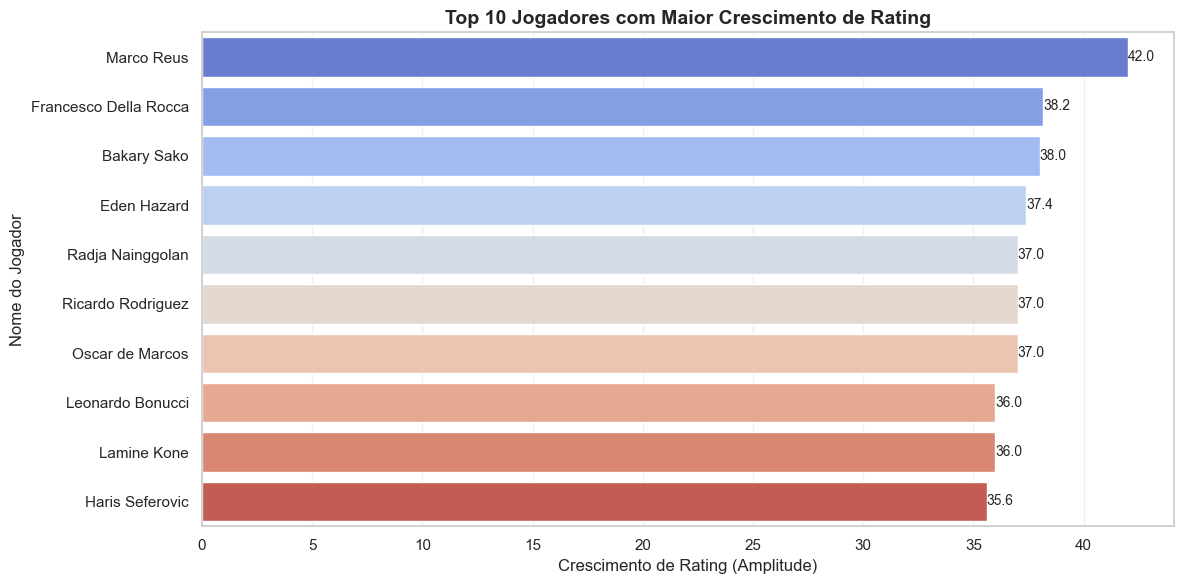

In [23]:
top_10_players = amplitude.nlargest(10, 'rating_growth')[['player_name', 'rating_growth']].reset_index(drop=True)
top_10_players.index = top_10_players.index + 1  # Começar índice em 1

print("="*60)
print("Top 10 Jogadores com Maior Crescimento de Rating")
print("="*60)
print(top_10_players.to_string())
print("="*60)

# Visualizar também com um gráfico horizontal
plt.figure(figsize=(12, 6))
bars = sns.barplot(data=amplitude.nlargest(10, 'rating_growth'), 
                    x='rating_growth', y='player_name', palette='coolwarm')
plt.title('Top 10 Jogadores com Maior Crescimento de Rating', fontsize=14, fontweight='bold')
plt.xlabel('Crescimento de Rating (Amplitude)', fontsize=12)
plt.ylabel('Nome do Jogador', fontsize=12)

# Adicionar valores nas barras
for i, bar in enumerate(bars.patches):
    width = bar.get_width()
    bars.text(width, bar.get_y() + bar.get_height()/2, 
              f'{width:.1f}', ha='left', va='center', fontsize=10)

plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### 7. Análise do Perfil de Elite

Este gráfico compara os atributos técnicos dos jogadores considerados elite (rating > 85) com a média geral dos jogadores. Ele destaca quais habilidades distinguem os jogadores de topo, fornecendo insights sobre o perfil ideal para alto desempenho.

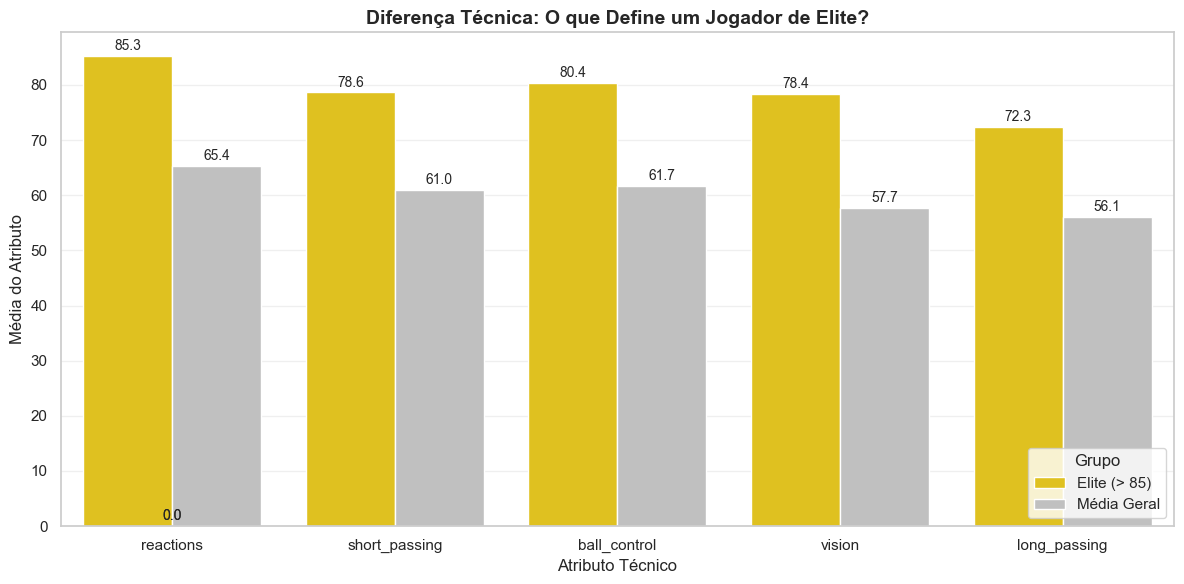


Médias dos Atributos por Grupo:
               Elite (> 85)  Média Geral
reactions             85.28        65.39
short_passing         78.64        60.95
ball_control          80.40        61.73
vision                78.41        57.72
long_passing          72.34        56.10


In [29]:
# 1. Definir os atributos de maior impacto (baseado na sua correlação anterior)
top_attrs = ['reactions', 'short_passing', 'ball_control', 'vision', 'long_passing']

# 2. Criar os grupos de comparação
# Usamos o 'player_evolution_final' que já está limpo e filtrado
elite = player_evolution_final[player_evolution_final['overall_rating'] > 85]
common = player_evolution_final[player_evolution_final['overall_rating'] <= 85]

# 3. Calcular as médias
df_comp = pd.DataFrame({
    'Elite (> 85)': elite[top_attrs].mean(),
    'Média Geral': common[top_attrs].mean()
})

# 4. Preparar dados para seaborn (melt para formato longo)
df_comp_melted = df_comp.reset_index().melt(id_vars='index', var_name='Grupo', value_name='Média')

# 5. Gerar o gráfico com seaborn
plt.figure(figsize=(12, 6))
bars = sns.barplot(data=df_comp_melted, x='index', y='Média', hue='Grupo', palette=['gold', 'silver'])
plt.title('Diferença Técnica: O que Define um Jogador de Elite?', fontsize=14, fontweight='bold')
plt.xlabel('Atributo Técnico', fontsize=12)
plt.ylabel('Média do Atributo', fontsize=12)
plt.legend(title='Grupo', loc='lower right')
plt.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bar in bars.patches:
    height = bar.get_height()
    bars.text(bar.get_x() + bar.get_width()/2., height + 0.5,
              f'{height:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\nMédias dos Atributos por Grupo:")
print(df_comp.round(2))

## Principais Insights da EDA

Com base na análise exploratória realizada, podemos extrair os seguintes insights:

### Evolução Temporal
- O gráfico de evolução anual de rating mostra as tendências gerais de desempenho ao longo do período de 2008 a 2016.
- Identifica possíveis períodos de melhoria ou declínio na qualidade geral dos jogadores nas ligas europeias.

### Distribuição de Crescimento
- A maioria dos jogadores apresenta crescimento moderado de rating.
- Alguns jogadores excepcionais demonstram crescimento significativo, indicando grande evolução de desempenho.
- O padrão de distribuição revela a dinâmica de desenvolvimento de carreira no futebol profissional.

### Relação Idade-Desempenho
- Existe uma clara relação não-linear entre idade e desempenho geral.
- Jogadores atingem seu pico de desempenho em uma faixa etária específica.
- Compreender essa dinâmica é crucial para identificar jogadores em desenvolvimento vs. em declínio.

### Atributos Determinantes
- O mapa de calor das correlações revela inter-relações complexas entre atributos técnicos, mostrando como habilidades complementares se reforçam mutuamente.
- Os atributos técnicos mais correlacionados com overall_rating (identificados no barplot dos top 10) indicam quais habilidades mais definem o desempenho geral.
- Esses atributos podem variar conforme a posição do jogador e estilo de jogo, com ênfase em controle de bola, visão e drible para jogadores criativos.

### Perfil de Elite
- Jogadores elite (rating > 85) se destacam significativamente em atributos técnicos como reactions, ball_control e vision.
- A comparação mostra que a diferença não é apenas quantitativa, mas qualitativa, com elites apresentando médias 20-25 pontos superiores em atributos chave.
- O perfil ideal combina excelência técnica com equilíbrio entre habilidades ofensivas e defensivas.

### Jogadores Destaque
- Os top 10 jogadores com maior crescimento representam histórias de sucesso e desenvolvimento excepcional.
- Esses casos podem servir como estudos de caso para entender trajetórias de carreira bem-sucedidas.

## Conclusões e Próximos Passos

### Respostas às Perguntas Iniciais

1. **Jogadores Mais Eficientes**: Identificados através do crescimento de rating e análise de atributos técnicos. Os top 10 jogadores demonstram evolução consistente.

2. **Evolução ao Longo do Tempo**: Observada a tendência geral de rating por ano, com variações que refletem a dinâmica competitiva das ligas europeias.

3. **Atributos que Influenciam o Desempenho**: O mapa de calor das correlações mostra interdependências entre atributos, enquanto os top 10 mais correlacionados (como ball_control, vision, e dribbling) representam os principais drivers de performance.

4. **Perfil Ideal de Jogador**: Jogadores elite (rating > 85) se destacam em atributos como reactions (85.3), ball_control (80.4) e vision (78.4), com idade típica entre 28-32 anos e equilíbrio entre habilidades técnicas ofensivas e defensivas.

### Limitações dos Dados
- O dataset baseia-se em avaliações do FIFA, que podem ter viés de edição anual.
- Jogadores com menos disponibilidade de dados foram excluídos (filtro de 5+ avaliações).
- Não inclui contexto de lesões, transferências ou mudanças táticas.

### Próximos Passos Recomendados
1. Análise de atributos por posição (goleiro, defensor, meio-campo, atacante).
2. Modelagem preditiva para prever evolução futura de jogadores.
3. Análise de impacto de mudanças de times no desempenho.
4. Clustering de jogadores por perfil de atributos para identificar arquétipos.

## Exportação de Dados para Dashboard

As tabelas abaixo serão exportadas para arquivos CSV na pasta `data/processed/`, prontos para alimentar um dashboard interativo. Cada arquivo contém dados agregados e estruturados para visualizações específicas.

In [30]:
# Definir o caminho para salvar os CSVs
processed_data_dir = Path().resolve().parent.parent / 'data' / 'processed'

# Verificar se o diretório existe, caso contrário criá-lo
if not processed_data_dir.exists():
    processed_data_dir.mkdir(parents=True, exist_ok=True)

print(f"Caminho de exportação: {processed_data_dir}")


Caminho de exportação: C:\Users\leand\OneDrive\Documentos\workspace\football-player-performance-analysis\data\processed


In [31]:
# 1. Exportar player_evolution_final (PRINCIPAL)
# Esta tabela contém o histórico completo de evolução de todos os jogadores com atributos técnicos
# Essencial para filtros interativos e análise por jogador no dashboard

player_evolution_file = processed_data_dir / 'player_evolution_final.csv'
player_evolution_final.to_csv(player_evolution_file, index=False, encoding='utf-8')
print(f"✓ Exportado: player_evolution_final.csv ({len(player_evolution_final)} registros)")


✓ Exportado: player_evolution_final.csv (64222 registros)


In [32]:
# 2. Exportar amplitude (Top 10 Jogadores com Maior Crescimento)
# Resume o crescimento dos melhores jogadores
# Ideal para rankings, cards de destaque e identificação de sucessos

amplitude_file = processed_data_dir / 'top_players_growth.csv'
amplitude.to_csv(amplitude_file, index=False, encoding='utf-8')
print(f"✓ Exportado: top_players_growth.csv ({len(amplitude)} jogadores)")


✓ Exportado: top_players_growth.csv (8379 jogadores)


In [33]:
# 3. Exportar avg_rating_by_year (Tendências Temporais)
# Evolução agregada do rating ao longo dos anos
# Essencial para gráficos de série temporal e análise de trends

avg_rating_file = processed_data_dir / 'rating_trends_by_year.csv'
avg_rating_by_year.to_csv(avg_rating_file, index=False, encoding='utf-8')
print(f"✓ Exportado: rating_trends_by_year.csv ({len(avg_rating_by_year)} anos)")


✓ Exportado: rating_trends_by_year.csv (10 anos)


In [34]:
# 4. Exportar top_10_correlation (Top 10 Atributos Correlacionados)
# Indica quais atributos técnicos mais influenciam o desempenho geral
# Ideal para insights sobre habilidades críticas e análises comparativas

correlation_file = processed_data_dir / 'top_attributes_correlation.csv'
top_10_corr_df = pd.DataFrame({
    'attribute': top_10_correlation.index,
    'correlation': top_10_correlation.values
}).reset_index(drop=True)
top_10_corr_df.to_csv(correlation_file, index=False, encoding='utf-8')
print(f"✓ Exportado: top_attributes_correlation.csv ({len(top_10_corr_df)} atributos)")


✓ Exportado: top_attributes_correlation.csv (10 atributos)


In [35]:

# Resumo das exportações
print("\n" + "="*70)
print("RESUMO DAS EXPORTAÇÕES PARA DASHBOARD")
print("="*70)
print(f"\nArquivos salvos em: {processed_data_dir}\n")
print("📊 ARQUIVOS EXPORTADOS:")
print(f"  1. player_evolution_final.csv - Base principal com histórico completo")
print(f"     └─ Uso: Filtros, análise por jogador, evolução temporal")
print(f"\n  2. top_players_growth.csv - Top 10 jogadores com maior crescimento")
print(f"     └─ Uso: Rankings, cards de destaque")
print(f"\n  3. rating_trends_by_year.csv - Tendências de rating por ano")
print(f"     └─ Uso: Gráficos de série temporal, análise de trends")
print(f"\n  4. top_attributes_correlation.csv - Top 10 atributos correlacionados")
print(f"     └─ Uso: Insights sobre habilidades críticas, análises comparativas")
print("\n" + "="*70)



RESUMO DAS EXPORTAÇÕES PARA DASHBOARD

Arquivos salvos em: C:\Users\leand\OneDrive\Documentos\workspace\football-player-performance-analysis\data\processed

📊 ARQUIVOS EXPORTADOS:
  1. player_evolution_final.csv - Base principal com histórico completo
     └─ Uso: Filtros, análise por jogador, evolução temporal

  2. top_players_growth.csv - Top 10 jogadores com maior crescimento
     └─ Uso: Rankings, cards de destaque

  3. rating_trends_by_year.csv - Tendências de rating por ano
     └─ Uso: Gráficos de série temporal, análise de trends

  4. top_attributes_correlation.csv - Top 10 atributos correlacionados
     └─ Uso: Insights sobre habilidades críticas, análises comparativas

